<a href="https://colab.research.google.com/github/pacarma4/NLP/blob/main/Analisis_artistas_Pol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

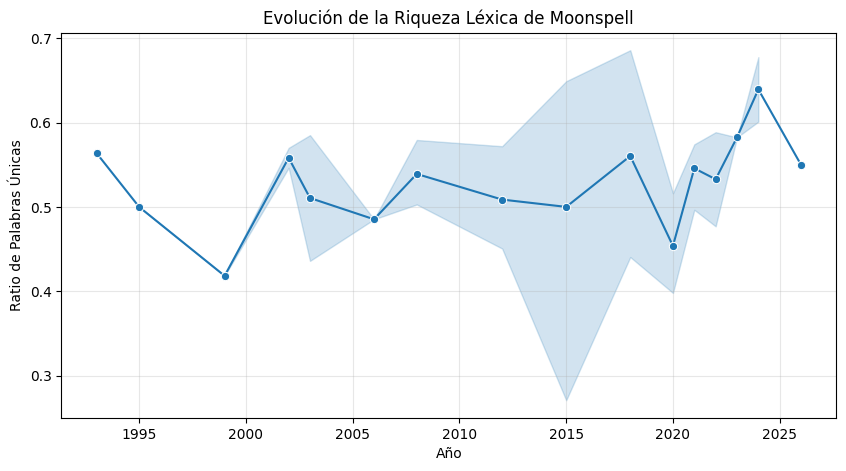

,lyrics,artist_clean,genre_clean,word_count,song_norm,song,year
0,"Hey you little Jesus' bride, why have you smil...",moonspell,Metal,197,let the children cum to me...,Let The Children Cum To Me...,2008
1,"I am the moment, the soul\nThe moment that end...",moonspell,Metal,219,memento mori,Memento Mori,2020
2,Vanishing act inside the weak\nIn need of you ...,moonspell,Metal,174,once it was ours!,Once It Was Ours!,2020
3,Father Satan send the Serpent\nPoison me with ...,moonspell,Metal,152,serpent angel,Serpent Angel,2024
4,"And we travel into the darkening,\na couldn't ...",moonspell,Metal,188,the darkening,The Darkening,2003


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargar el dataset
df_años = pd.read_csv("songs_with_years_processed.csv")
df_años.head()

artista_objetivo = "moonspell"
genero_objetivo = "Metal"

# Aislar el artista y ordenarlo cronológicamente
df_artista = df_años[df_años['artist_clean'] == artista_objetivo].copy()
df_artista = df_artista.sort_values('year')

# Calcular la "Riqueza Léxica" (porcentaje de palabras únicas por canción)
# Convertimos las letras a minúsculas y separamos por espacios
df_artista['unique_words'] = df_artista['lyrics'].apply(lambda x: len(set(str(x).lower().split())))
df_artista['lexical_richness'] = df_artista['unique_words'] / df_artista['word_count']

# Gráfico de evolución temporal de la riqueza léxica
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_artista, x='year', y='lexical_richness', marker='o')
plt.title(f'Evolución de la Riqueza Léxica de {artista_objetivo.capitalize()}')
plt.ylabel('Ratio de Palabras Únicas')
plt.xlabel('Año')
plt.grid(True, alpha=0.3)
plt.show()

df_años.head()

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Agrupar las letras: Todas las de Moonspell vs Todas las del resto del Metal
letras_artista = " ".join(df_artista['lyrics'].astype(str).tolist())

df_resto_metal = df_años[(df_años['genre_clean'] == genero_objetivo) & (df_años['artist_clean'] != artista_objetivo)]
letras_resto = " ".join(df_resto_metal['lyrics'].astype(str).tolist())

corpus = [letras_artista, letras_resto]

# Inicializar TF-IDF (quitando stopwords en inglés)
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = vectorizer.fit_transform(corpus)

# Convertir a DataFrame para verlo fácil
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=[artista_objetivo, 'Resto del Metal'])

# Obtener las 10 palabras con mayor puntuación TF-IDF para el artista
palabras_firma = df_tfidf.loc[artista_objetivo].sort_values(ascending=False).head(10)

print(f"--- Las 10 palabras más características de {artista_objetivo.capitalize()} ---")
print(palabras_firma)

--- Las 10 palabras más características de Moonspell ---
inside    0.336747
let       0.253855
place     0.212410
bee       0.176145
love      0.176145
man       0.170964
just      0.160602
time      0.160602
men       0.155422
know      0.139879
Name: moonspell, dtype: float64


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
/tmp/ipykernel_10943/2040952795.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentimiento_anual, x='year', y='sentiment_score', palette='coolwarm')


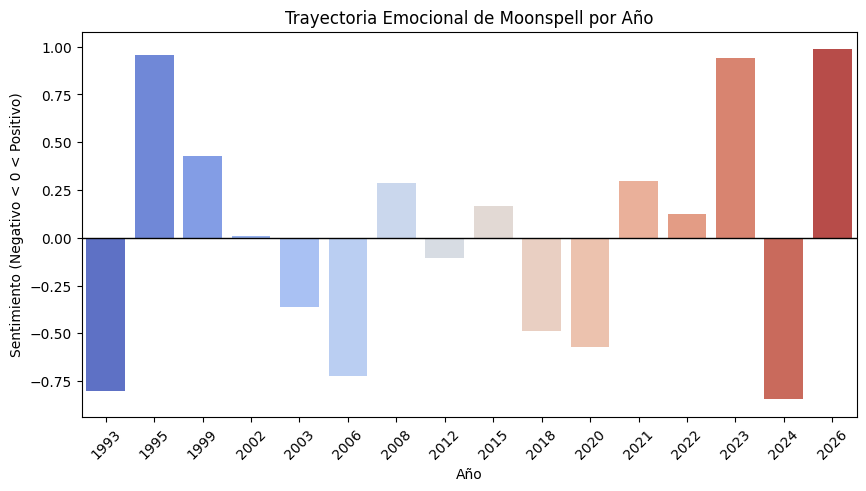

In [3]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Descargar el léxico de VADER (solo hace falta ejecutarlo una vez)
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

# Aplicar el analizador de sentimiento a cada canción
df_artista['sentiment_score'] = df_artista['lyrics'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Agrupar por año para ver la tendencia (media de sentimiento por año)
sentimiento_anual = df_artista.groupby('year')['sentiment_score'].mean().reset_index()

# Gráfico de la trayectoria emocional
plt.figure(figsize=(10, 5))
sns.barplot(data=sentimiento_anual, x='year', y='sentiment_score', palette='coolwarm')
plt.title(f'Trayectoria Emocional de {artista_objetivo.capitalize()} por Año')
plt.ylabel('Sentimiento (Negativo < 0 < Positivo)')
plt.xlabel('Año')
plt.axhline(0, color='black', linewidth=1) # Línea base neutra
plt.xticks(rotation=45)
plt.show()

Procesando canciones con spaCy...


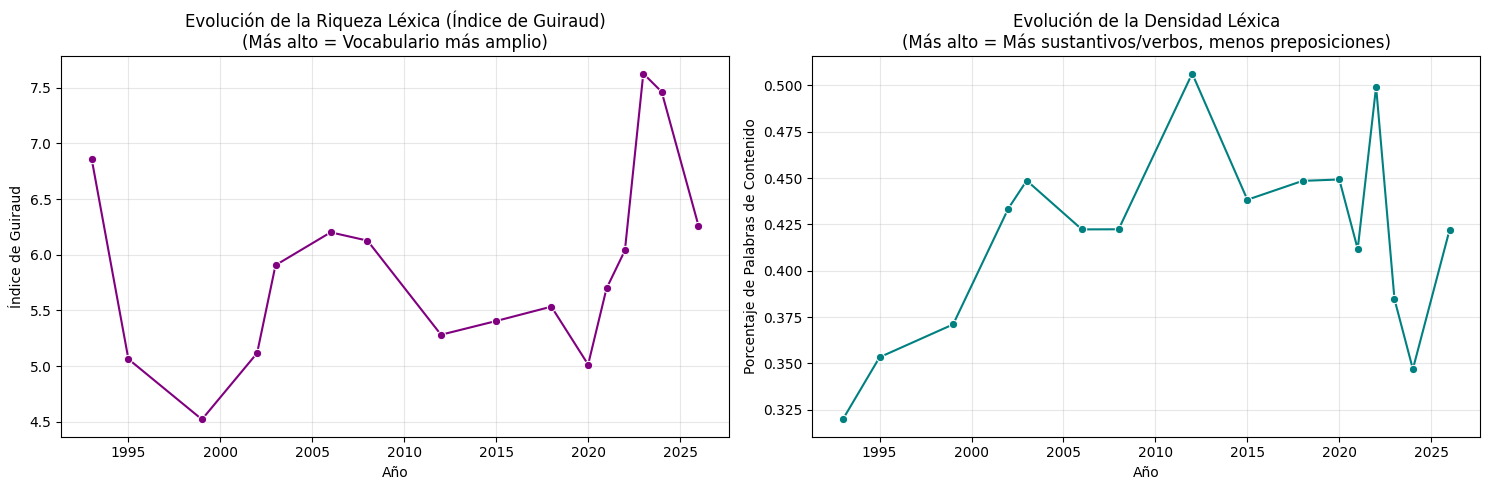


--- Top 10 canciones MÁS densas de Moonspell ---
                                song  year  lexical_density  guiraud_index
1286                       Angelizer  2020         0.559322       7.516460
1285                       Angelizer  2020         0.559322       7.516460
1273                     White Skies  2012         0.547619       5.256138
1272                        Soulsick  2020         0.535032       4.469287
1307  Dreamless (lucifer And Lilith)  2018         0.526316       5.994149
1282                      Alpha Noir  2012         0.524590       5.794288
1301                  Common Prayers  2022         0.515924       5.267373
1276              A Greater Darkness  2012         0.512821       5.604485
1279                          Abysmo  2008         0.511765       6.672595
1316                      Fireseason  2012         0.509615       4.804845


In [4]:
import pandas as pd
import spacy
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el modelo en inglés de spaCy
# Usamos 'en_core_web_sm' por ser rápido, ideal para conjuntos grandes
nlp = spacy.load("en_core_web_sm")

# Supongamos que tu dataframe se llama df_años
# df_años = pd.read_csv("songs_with_years_processed.csv")

# 1. Filtramos las canciones de Moonspell y las ordenamos por año
df_moonspell = df_años[df_años['artist_clean'] == 'moonspell'].copy()
df_moonspell = df_moonspell.sort_values('year')

# Listas para guardar nuestras nuevas métricas
guiraud_indices = []
lexical_densities = []

print("Procesando canciones con spaCy...")

for index, row in df_moonspell.iterrows():
    texto = str(row['lyrics'])

    # Procesar el texto con spaCy
    doc = nlp(texto)

    # ---------------------------------------------------------
    # MÉTRICA 1: Índice de Guiraud (CTTR - Root Type-Token Ratio)
    # ---------------------------------------------------------
    # El Índice de Guiraud es más robusto frente a canciones largas que el TTR normal.
    # Fórmula: Tipos (lemmas únicos) / Raíz Cuadrada de Tokens (palabras totales)

    # Filtramos signos de puntuación y espacios para el conteo real de palabras
    tokens = [token for token in doc if not token.is_punct and not token.is_space]

    # Usamos lemas (palabra base) para contar palabras únicas ("running" y "ran" cuentan como 1: "run")
    tipos_unicos = set([token.lemma_.lower() for token in tokens])

    num_tokens = len(tokens)
    num_tipos = len(tipos_unicos)

    if num_tokens > 0:
        # Calculamos el Índice de Guiraud
        guiraud = num_tipos / math.sqrt(num_tokens)
    else:
        guiraud = 0

    guiraud_indices.append(guiraud)

    # ---------------------------------------------------------
    # MÉTRICA 2: Densidad Léxica (Lexical Density)
    # ---------------------------------------------------------
    # Calcula el porcentaje de "palabras con contenido" (Sustantivos, Verbos, Adjetivos, Adverbios)
    # frente al total de palabras. Nos dice si la canción es puramente narrativa/descriptiva
    # o si está llena de pronombres/conjunciones (relleno gramatical).

    # POS tags de contenido (Universal Part-of-Speech tags)
    content_pos_tags = {'NOUN', 'VERB', 'ADJ', 'ADV'}

    content_words = [token for token in tokens if token.pos_ in content_pos_tags]

    if num_tokens > 0:
        # Porcentaje de palabras con contenido sobre el total
        densidad = len(content_words) / num_tokens
    else:
        densidad = 0

    lexical_densities.append(densidad)

# Añadimos las métricas calculadas al dataframe
df_moonspell['guiraud_index'] = guiraud_indices
df_moonspell['lexical_density'] = lexical_densities

# Agrupamos por año para ver la evolución y suavizar variaciones de canciones sueltas
df_tendencia = df_moonspell.groupby('year')[['guiraud_index', 'lexical_density']].mean().reset_index()

# ---------------------------------------------------------
# VISUALIZACIÓN: Evolución de las métricas
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Índice de Guiraud (Riqueza Léxica corregida)
sns.lineplot(data=df_tendencia, x='year', y='guiraud_index', marker='o', color='purple', ax=ax1)
ax1.set_title('Evolución de la Riqueza Léxica (Índice de Guiraud)\n(Más alto = Vocabulario más amplio)')
ax1.set_xlabel('Año')
ax1.set_ylabel('Índice de Guiraud')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Densidad Léxica
sns.lineplot(data=df_tendencia, x='year', y='lexical_density', marker='o', color='teal', ax=ax2)
ax2.set_title('Evolución de la Densidad Léxica\n(Más alto = Más sustantivos/verbos, menos preposiciones)')
ax2.set_xlabel('Año')
ax2.set_ylabel('Porcentaje de Palabras de Contenido')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar algunas canciones destacadas
print("\n--- Top 10 canciones MÁS densas de Moonspell ---")
print(df_moonspell[['song', 'year', 'lexical_density','guiraud_index']].sort_values(by='lexical_density', ascending=False).head(10))

In [ ]:
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# 1. Cargar y filtrar datos
# df_años = pd.read_csv("songs_with_years_processed.csv")
df_moonspell = df_años[df_años['artist_clean'] == 'moonspell'].copy()

# BERTopic necesita una lista de strings (documentos)
docs = df_moonspell['lyrics'].astype(str).tolist()

print(f"Entrenando modelo para {len(docs)} canciones de Moonspell...")

# 2. Configurar BERTopic
# Usamos CountVectorizer para quitar las 'stop words' en inglés y que no dominen los tópicos
vectorizer_model = CountVectorizer(stop_words="english")

# Iniciamos BERTopic
# min_topic_size=5: forzamos a crear un tópico si al menos 5 canciones hablan de lo mismo
topic_model = BERTopic(
    language="english",
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=5,
    vectorizer_model=vectorizer_model
)

# 3. Entrenar el modelo
# Esto puede tardar un par de minutos dependiendo de tu procesador
topics, probabilities = topic_model.fit_transform(docs)

# Añadimos el tópico predominante de vuelta a nuestro DataFrame
df_moonspell['topic_id'] = topics

# 4. Ver los resultados numéricos
# get_topic_info() nos devuelve un resumen de cuántas canciones hay por tópico y sus palabras clave
df_topic_info = topic_model.get_topic_info()
print("\n--- Resumen de Tópicos Encontrados ---")
print(df_topic_info[['Topic', 'Count', 'Name']].head(10))

# 5. Visualizaciones (¡La joya de la corona para vuestra presentación!)

# Gráfico 1: Gráfico de barras con las palabras más representativas de cada tópico
fig_barchart = topic_model.visualize_barchart(top_n_topics=6)
fig_barchart.show()

# Gráfico 2: Distancia inter-tópico (Muestra cómo se relacionan los temas en un espacio 2D)
fig_intertopic = topic_model.visualize_topics()
fig_intertopic.show()

# Gráfico 3: Evolución de los Tópicos a lo largo del tiempo (Topic Modeling Dinámico)
# Aquí usamos tu columna 'year' para ver si Moonspell hablaba de ciertas cosas en 2000 y de otras en 2020
timestamps = df_moonspell['year'].tolist()
topics_over_time = topic_model.topics_over_time(docs, timestamps, nr_bins=20)
fig_over_time = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=5)
fig_over_time.show()